<a href="https://colab.research.google.com/github/juanfloresponce2006-dot/Creaci-n-y-Visualizaci-n-de-KPI-s/blob/main/Borrador.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Parte 1 (Análisis de datos sintéticos), generación de base de datos aleatoria
import pandas as pd
import numpy as np

# Generar datos simulados
data = {'ID_Transaccion': range(1001, 1051),
        'Canal': np.random.choice(['Web Desktop', 'App Móvil'], 50, p=[0.4, 0.6]),
        'Metodo_Pago': np.random.choice(['Tarjeta Crédito', 'PayPal', 'Transferencia'], 50),
        'Total_Venta': np.random.randint(20, 500, 50), # Ventas entre $20 y $500
        'Categoria': np.random.choice(['Electrónica', 'Moda', 'Hogar'], 50)}

df_sintetico = pd.DataFrame(data)

df_sintetico.tail()

,ID_Transaccion,Canal,Metodo_Pago,Total_Venta,Categoria
45,1046,Web Desktop,PayPal,273,Moda
46,1047,App Móvil,Transferencia,432,Electrónica
47,1048,Web Desktop,PayPal,318,Moda
48,1049,Web Desktop,Tarjeta Crédito,292,Moda
49,1050,App Móvil,PayPal,95,Hogar


/tmp/ipykernel_3387/1785508026.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = df_sintetico.groupby('Canal')['Total_Venta'].sum().reset_index(),
/tmp/ipykernel_3387/1785508026.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sintetico.groupby('Canal')['Total_Venta'].mean().reset_index(),
/tmp/ipykernel_3387/1785508026.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_sintetico, x='Canal', ax=axes[1, 0], palette='coolwarm')


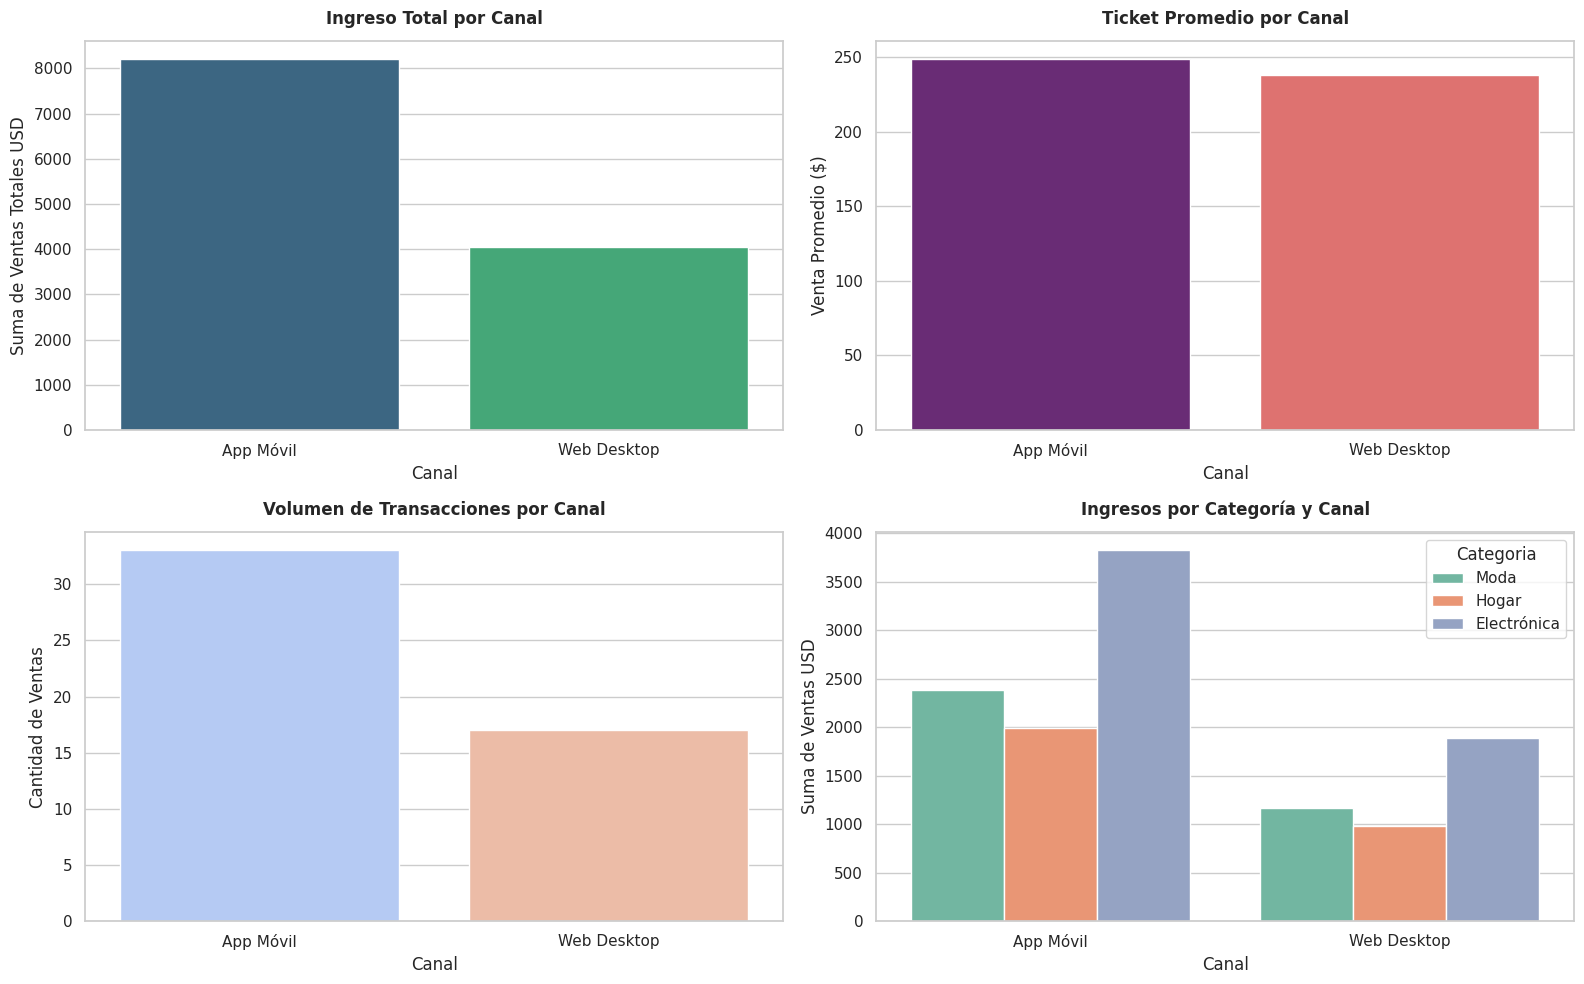

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style = "whitegrid")
fig, axes = plt.subplots(2, 2, figsize = (16, 10))

# KPI 1: Ingreso Total por Estrategia/Canal
sns.barplot(data = df_sintetico.groupby('Canal')['Total_Venta'].sum().reset_index(),
            x = 'Canal', y = 'Total_Venta', ax = axes[0, 0], palette = 'viridis')

axes[0, 0].set_title('Ingreso Total por Canal', fontdict = {"fontsize": 12, "fontweight": "bold"}, pad = 12)
axes[0, 0].set_ylabel('Suma de Ventas Totales USD')

# KPI 2: Ticket Promedio por Canal
sns.barplot(data=df_sintetico.groupby('Canal')['Total_Venta'].mean().reset_index(),
            x='Canal', y='Total_Venta', ax=axes[0, 1], palette='magma')
axes[0, 1].set_title('Ticket Promedio por Canal', fontdict = {"fontsize": 12, "fontweight": "bold"}, pad = 12)
axes[0, 1].set_ylabel('Venta Promedio ($)')

# KPI 3: Volumen de Transacciones por Canal
sns.countplot(data=df_sintetico, x='Canal', ax=axes[1, 0], palette='coolwarm')
axes[1, 0].set_title('Volumen de Transacciones por Canal', fontdict = {"fontsize": 12, "fontweight": "bold"}, pad = 12)
axes[1, 0].set_ylabel('Cantidad de Ventas')

# KPI 4: Ventas por Categoría y Canal
sns.barplot(data=df_sintetico, x='Canal', y='Total_Venta', hue='Categoria', estimator=sum, errorbar=None, ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Ingresos por Categoría y Canal', fontdict = {"fontsize": 12, "fontweight": "bold"}, pad = 12)
axes[1, 1].set_ylabel('Suma de Ventas USD')

plt.tight_layout()
plt.show()

1. Ingreso Total por Canal
La estrategia de M-Commerce (App Móvil) genera una rentabilidad bruta mayor frente al E-Commerce tradicional (Web Desktop). Esto demuestra que dirigir los esfuerzos operativos hacia la plataforma con mayor tráfico impacta directamente en la facturación agregada.

2. Ticket Promedio por Canal
Aunque el M-Commerce predomina en el acumulado de ingresos, el ticket promedio (la media por venta) se mantiene muy parejo en ambos canales. El usuario móvil no gasta más dinero por transacción que el usuario de escritorio, simplemente realiza compras con mayor frecuencia.

3. Cantidad de Transacciones por Canal
De las 50 transacciones, la mayoría absoluta ocurre en la App Móvil, esto confirma la tendencia de que los consumidores priorizan la inmediatez y la fricción reducida que ofrece un smartphone para concretar pagos.

4. Ingresos por Categoría y Canal
Al desglosar las ventas, las categorías (Electrónica, Moda, Hogar) muestran un comportamiento transaccional relativamente parecido debido a la aleatoriedad de los datos. Sin embargo, las barras de M-Commerce superan a las de Web Desktop en las tres divisiones.

#¿Es la estrategia de M-Commerce más rentable que el E-Commerce tradicional?

 Sí, lo es. Sin embargo, el análisis de estos 4 KPIs nos permite entender que esta rentabilidad es impulsada netamente por el volumen de adopción y no por un aumento en el gasto por pedido. Esto implica que la rentabilidad depende de la disponibilidad de la aplicación; cualquier caída en el servicio móvil representaría un impacto financiero mucho más crítico que una falla en la plataforma web.

In [23]:
df_ecommerce = pd.read_csv("/content/Train.csv")
df_ecommerce.duplicated().sum()

np.int64(0)

In [22]:
df_ecommerce.isnull().sum()

,0
ID,0
Warehouse_block,0
Mode_of_Shipment,0
Customer_care_calls,0
Customer_rating,0
Cost_of_the_Product,0
Prior_purchases,0
Product_importance,0
Gender,0
Discount_offered,0


In [25]:
df_ecommerce.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


/tmp/ipykernel_3387/2549070574.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = df_ecommerce.groupby('Mode_of_Shipment')['Cost_of_the_Product'].mean().reset_index(),
/tmp/ipykernel_3387/2549070574.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_ecommerce.groupby('Mode_of_Shipment')['Weight_in_gms'].mean().reset_index(),


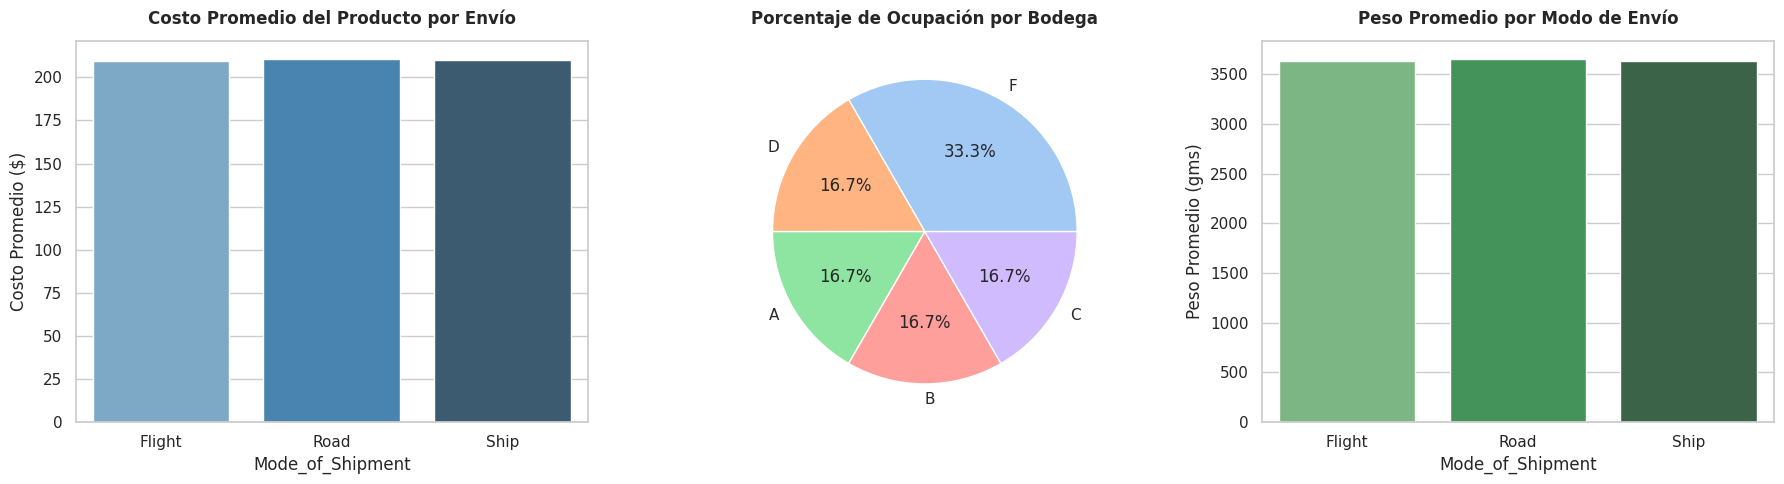

In [24]:
fig, axes = plt.subplots(1, 3, figsize = (16, 5))

# Costo Promedio del Producto por Modo de Transporte
sns.barplot(data = df_ecommerce.groupby('Mode_of_Shipment')['Cost_of_the_Product'].mean().reset_index(),
            x='Mode_of_Shipment', y='Cost_of_the_Product', ax=axes[0], palette='Blues_d')

axes[0].set_title('Costo Promedio del Producto por Envío', fontdict = {"fontsize": 12, "fontweight": "bold"}, pad = 12)
axes[0].set_ylabel('Costo Promedio ($)')

# Volumen de Ocupación por Bloque de Bodega
warehouse_counts = df_ecommerce['Warehouse_block'].value_counts()
axes[1].pie(warehouse_counts, labels=warehouse_counts.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
axes[1].set_title('Porcentaje de Ocupación por Bodega', fontdict = {"fontsize": 12, "fontweight": "bold"}, pad = 12)

# Peso Promedio del Producto por Modo de Envío
sns.barplot(data = df_ecommerce.groupby('Mode_of_Shipment')['Weight_in_gms'].mean().reset_index(),
            x='Mode_of_Shipment', y='Weight_in_gms', ax=axes[2], palette='Greens_d')

axes[2].set_title('Peso Promedio por Modo de Envío', fontdict = {"fontsize": 12, "fontweight": "bold"}, pad = 12)
axes[2].set_ylabel('Peso Promedio (gms)')

plt.tight_layout()
plt.show()

1. Costo Promedio del Producto por Modo de Transporte

    Al observar el valor promedio de los productos distribuidos por canal (Barco, Avión y Carretera), notamos que no existe una dispersión drástica entre ellos; el costo medio se mantiene bastante nivelado. Esto nos indica que la empresa no está reservando exclusivamente las vías más rápidas (y costosas, como el avión) para los productos de mayor valor económico.

2. Volumen de Ocupación por Bloque de Bodega
    El gráfico circular revela claramente cómo está estructurada la carga operativa de la infraestructura. El Bloque F administra un volumen significativamente mayor, mientras que los bloques A, B, C y D manejan proporciones similates. Esto nos permite concluir que el Bloque F opera como la instalación principal o "hub" central.

3. Peso Promedio del Producto por Modo de Envío
    Al analizar la masa física que se mueve por cada canal, observamos que el peso promedio también es sorprendentemente similar entre envíos marítimos, aéreos y terrestres. Aquí existe una alerta operativa: enviar carga pesada por vía aérea (Flight) representa un impacto financiero mucho más alto que hacerlo por barco (Ship). Si la empresa está enviando productos de gran peso volumétrico por avión con una frecuencia alta, se está incurriendo en un gasto logístico que castiga fuertemente el margen de rentabilidad.

#Conclusión General de Logística:
  La infraestructura operativa muestra una centralización en un solo bloque de bodega (Bloque F). Además, la distribución de los envíos sugiere que las políticas de asignación de transporte necesitan optimización, se debería implementar una regla de negocio en el TPS que restrinja el envío aéreo de productos demasiado pesados o de bajo costo, priorizando el transporte marítimo o terrestre para mejorar el margen operativo.

/tmp/ipykernel_3387/4135125006.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = df_ecommerce.groupby('Product_importance')['Discount_offered'].mean().reset_index(),


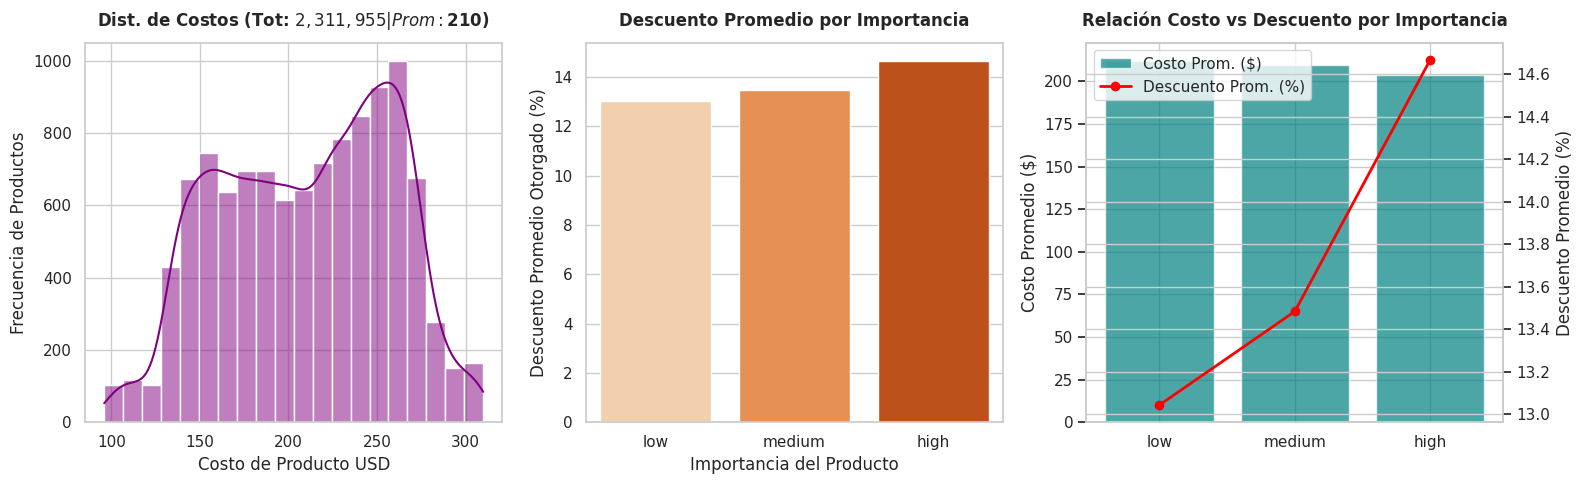

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Ingreso Total Bruto y Costo Promedio
ingreso_total = df_ecommerce['Cost_of_the_Product'].sum()
costo_promedio = df_ecommerce['Cost_of_the_Product'].mean()

sns.histplot(data = df_ecommerce, x = 'Cost_of_the_Product', bins = 20, kde = True, ax = axes[0], color = 'purple')

axes[0].set_title(f'Dist. de Costos (Tot: ${ingreso_total:,.0f} | Prom: ${costo_promedio:,.0f})', fontdict = {"fontsize": 12, "fontweight": "bold"}, pad = 12)
axes[0].set_xlabel('Costo de Producto USD')
axes[0].set_ylabel('Frecuencia de Productos')

# Porcentaje de Descuento Promedio Otorgado
sns.barplot(data = df_ecommerce.groupby('Product_importance')['Discount_offered'].mean().reset_index(),
            x = 'Product_importance', y = 'Discount_offered', ax = axes[1], palette = 'Oranges', order = ['low', 'medium', 'high'])
axes[1].set_title('Descuento Promedio por Importancia', fontdict = {"fontsize": 12, "fontweight": "bold"}, pad = 12)
axes[1].set_ylabel('Descuento Promedio Otorgado (%)')
axes[1].set_xlabel('Importancia del Producto')

# Margen Relativo (Costo vs Descuento)
importance_grp = df_ecommerce.groupby('Product_importance')[['Cost_of_the_Product', 'Discount_offered']].mean().reindex(['low', 'medium', 'high'])

ax2 = axes[2].twinx()
axes[2].bar(importance_grp.index, importance_grp['Cost_of_the_Product'], color = 'teal', alpha = 0.7, label = 'Costo Prom. ($)')
ax2.plot(importance_grp.index, importance_grp['Discount_offered'], color = 'red', marker = 'o', lw = 2, label ='Descuento Prom. (%)')
axes[2].set_title('Relación Costo vs Descuento por Importancia', fontdict = {"fontsize": 12, "fontweight": "bold"}, pad = 12)
axes[2].set_ylabel('Costo Promedio ($)')
ax2.set_ylabel('Descuento Promedio (%)')


lines_1, labels_1 = axes[2].get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
axes[2].legend(lines_1 + lines_2, labels_1 + labels_2, loc = 'upper left')

plt.tight_layout()
plt.show()

1. Ingreso Total Bruto y Costo Promedio del Producto

    El histograma de distribución de costos revela cómo está el portafolio comercial de la empresa. Viendo la curva de frecuencias, podemos identificar que el catálogo no se concentra en productos de un único valor, sino que abarca un rango amplio, lo que mantiene un ticket promedio estable.

2. Porcentaje de Descuento Promedio Otorgado por Importancia

    Al analizar las barras de descuento cruzadas con la categoría Product_importance (Baja, Media y Alta), evaluamos la estrategia promocional. En una operación adecuada, los productos clasificados como de "alta importancia" (High) deberían mantener descuentos más conservadores para proteger el margen de ganancia.

3. Margen Teórico Relativo (Costo vs Descuento)

    Al sobreponer el costo promedio del artículo con el porcentaje de descuento otorgado, podemos evaluar la rentabilidad teórica. Idealmente, a mayor costo del producto, el porcentaje de descuento debería disminuir o mantenerse estrictamente controlado.

/tmp/ipykernel_3387/1122431904.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = df_ecommerce.groupby('Gender')['Customer_rating'].mean().reset_index(),
/tmp/ipykernel_3387/1122431904.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = df_ecommerce.groupby('Customer_rating')['Customer_care_calls'].mean().reset_index(),


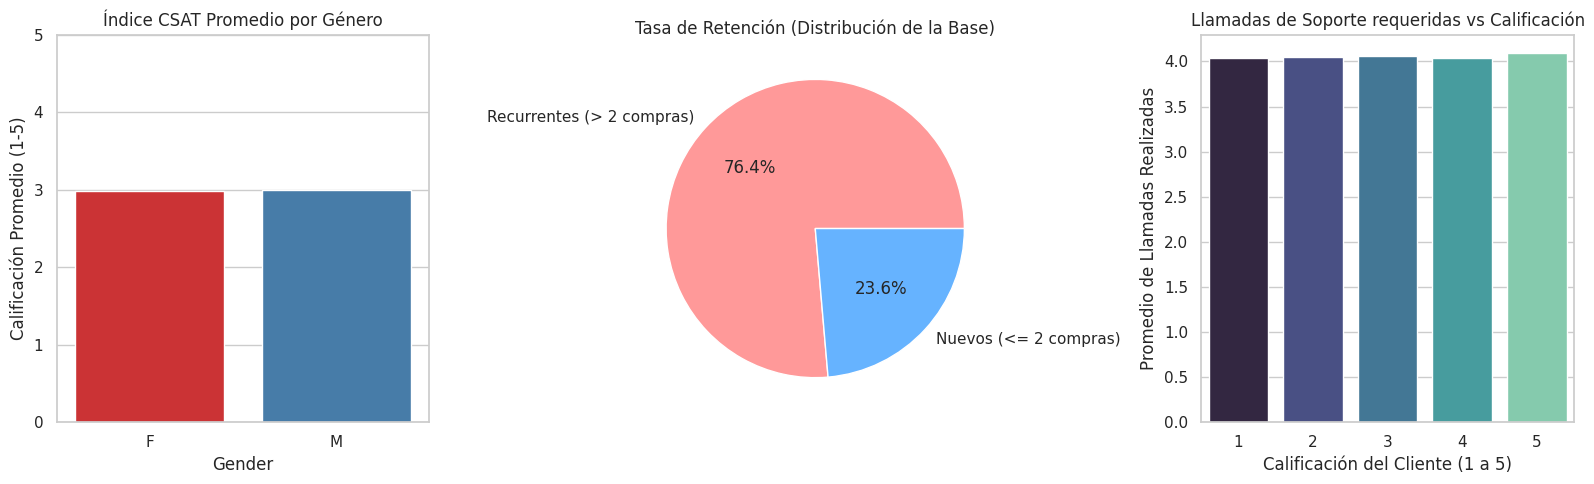

In [37]:
fig, axes = plt.subplots(1, 3, figsize = (16, 5))

# Índice de Satisfacción del Cliente (CSAT) Promedio
sns.barplot(data = df_ecommerce.groupby('Gender')['Customer_rating'].mean().reset_index(),
            x = 'Gender', y = 'Customer_rating', ax = axes[0], palette = 'Set1')

axes[0].set_title('Índice CSAT Promedio por Género')
axes[0].set_ylabel('Calificación Promedio (1-5)')
axes[0].set_ylim(0, 5)

# Tasa de Retención / Clientes Recurrentes
data['Tipo_Cliente'] = df_ecommerce['Prior_purchases'].apply(lambda x: 'Nuevos (<= 2 compras)' if x <= 2 else 'Recurrentes (> 2 compras)')
retencion_counts = data['Tipo_Cliente'].value_counts()
axes[1].pie(retencion_counts, labels = retencion_counts.index, autopct = '%1.1f%%', colors = ['#ff9999','#66b3ff'])
axes[1].set_title('Tasa de Retención (Distribución de la Base)')

# Carga de Soporte por Cliente
sns.barplot(data = df_ecommerce.groupby('Customer_rating')['Customer_care_calls'].mean().reset_index(),
            x = 'Customer_rating', y = 'Customer_care_calls', ax = axes[2], palette = 'mako')
axes[2].set_title('Llamadas de Soporte requeridas vs Calificación')
axes[2].set_ylabel('Promedio de Llamadas Realizadas')
axes[2].set_xlabel('Calificación del Cliente (1 a 5)')

plt.tight_layout()
plt.show()

1. Índice de Satisfacción del Cliente (CSAT) Promedio por Género

    Al observar el gráfico de barras, notamos una congruencia casi exacta en la calificación promedio otorgada tanto por hombres como por mujeres. Desde una perspectiva de auditoría, esto es un indicador positivo: la plataforma no presenta sesgos de diseño ni fricciones que afecten negativamente a un grupo específico.

2. Tasa de Retención (Distribución de la Base)

    El gráfico circular revela una métrica alentadora para la salud financiera del negocio: la gran mayoría de la base de datos (más del 70%) está compuesta por clientes "Recurrentes" (que han realizado 3 o más compras previas).

3. Distribución de Llamadas de Soporte vs Calificación
    El análisis del diagrama de caja (boxplot) arroja uno de los hallazgos más interesantes. Podríamos asumir empíricamente que una calificación baja (1 o 2 estrellas) generaría más llamadas de reclamo, y una calificación alta (4 o 5 estrellas) generaría menos. Sin embargo, la distribución y las medianas de llamadas al centro de soporte se mantienen constantes (alrededor de 4 llamadas por cliente) sin importar el nivel de satisfacción.

    Esto nos indica que el alto volumen de llamadas no es un debido a la insatisfacción del cliente, sino una deficiencia del proceso.